# Training Loss Graphs

## NS

<Figure size 1200x600 with 0 Axes>

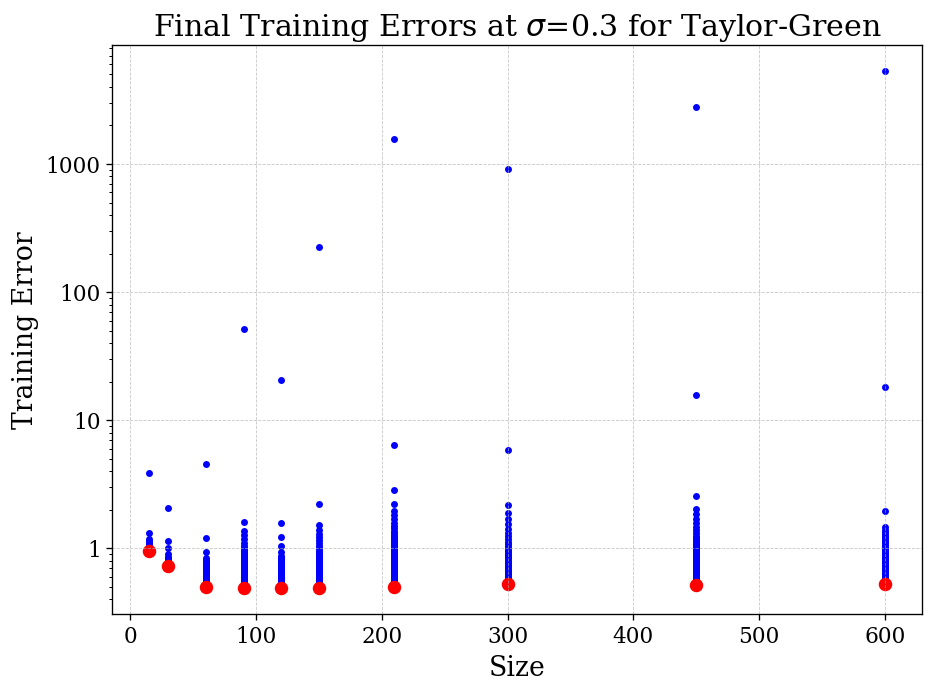

In [ ]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
file_name = ""
file = file_name.split("_")
results = np.load(file_name + ".npz")
train_errors = results['train']
test_errors = results['test']
d_Ns = ast.literal_eval(file[3])
iterations = int(file[7])
blue_dot_freq = 10
sigma = float(file[5])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'figure.dpi': 120
})

plt.figure(figsize=(10, 5))


colors = ['b']
plt.figure(figsize=(8,6))
for i, color in enumerate(colors):
  plt.scatter(3 * np.repeat(np.array(d_Ns), iterations / blue_dot_freq), train_errors[0,:,::blue_dot_freq],color="blue", s=10)
  plt.scatter(3 * np.array(d_Ns),train_errors[0,:,iterations - 1],color="red", s=50)
plt.yscale('log')
# plt.ylim(top=0.1)
# plt.ylim(bottom=0)
# plt.xscale('log')
# plt.axhline(y=sigma**2,color='red')

# ymin, ymax = plt.ylim()

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
# plt.gca().yaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

plt.xlabel("Size")
plt.ylabel("Training Error")
# plt.title(f"NS: Training Errors over widths:{d_Ns}, $\sigma$:{sigma}")
plt.title(f"Final Training Errors at $\sigma$={sigma} for Taylor-Green")

# plt.legend()
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.show()

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

## Poisson

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import ast
file_name = ""

file = file_name.split("_")
results = np.load(file_name + ".npz")
train_errors = results['train']
d_Ns = ast.literal_eval(file[3])
iterations = int(file[7])
blue_dot_freq = 100
sigma = float(file[5])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'figure.dpi': 120
})

plt.figure(figsize=(10, 5))

colors = ['b']
plt.figure(figsize=(8,6))
for i, color in enumerate(colors):
  plt.scatter(2 * np.repeat(np.array(d_Ns), iterations / blue_dot_freq), train_errors[0,0,:,::blue_dot_freq],color="blue", s=10)
  plt.scatter(2 * np.array(d_Ns),train_errors[0,0,:,iterations - 1],color="red", s=50)
plt.yscale('log')
plt.ylim(top=10)
plt.axhline(y=sigma**2,color='red')

ymin, ymax = plt.ylim()

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

plt.xlabel("Size")
plt.ylabel("Training Error")
plt.title(f"Final Training Errors at $\sigma$={sigma} for Poisson")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

## HJB

<Figure size 1200x600 with 0 Axes>

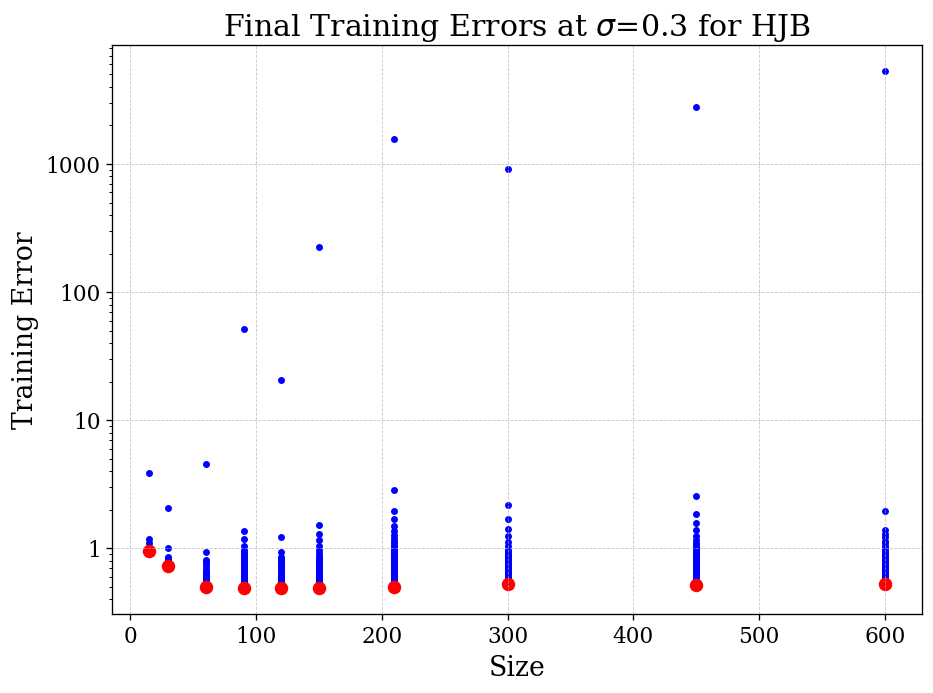

In [ ]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
file_name = ""
file = file_name.split("_")
results = np.load(file_name + ".npz")
train_errors = results['train']
test_errors = results['test']
d_Ns = ast.literal_eval(file[3])
iterations = int(file[7])
blue_dot_freq = 100
sigma = float(file[5])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'figure.dpi': 120
})

plt.figure(figsize=(10, 5))


colors = ['b']
plt.figure(figsize=(8,6))
for i, color in enumerate(colors):
  plt.scatter(3 * np.repeat(np.array(d_Ns), iterations / blue_dot_freq), train_errors[0,:,::blue_dot_freq],color="blue", s=10)
  plt.scatter(3 * np.array(d_Ns),train_errors[0,:,iterations - 1],color="red", s=50)
plt.yscale('log')
# plt.ylim(top=0.1)
# plt.ylim(bottom=0)
# plt.xscale('log')
# plt.axhline(y=sigma**2,color='red')

# ymin, ymax = plt.ylim()

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
# plt.gca().yaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

plt.xlabel("Size")
plt.ylabel("Training Error")
# plt.title(f"NS: Training Errors over widths:{d_Ns}, $\sigma$:{sigma}")
plt.title(f"Final Training Errors at $\sigma$={sigma} for HJB")

# plt.legend()
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.show()

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# Plots

## NS

0.010878976


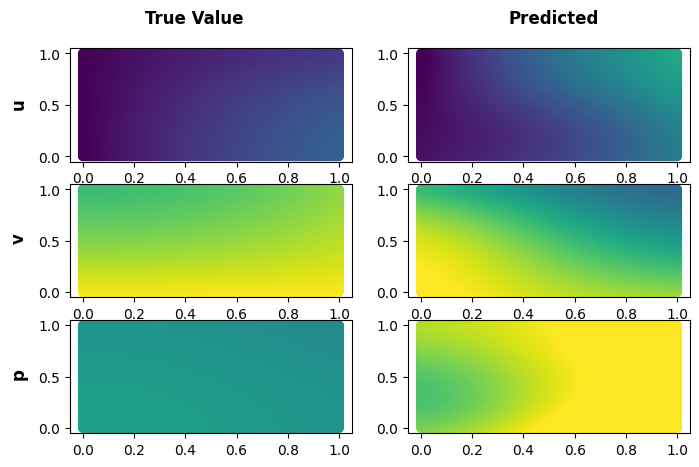

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from tqdm import tqdm

min_xyt, max_xyt = 0, 1
nu = 1
rho = 1

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3
beta = 10**-3
k = 3
class ExpReLU(torch.nn.Module):
    def forward(self, x):
        return torch.exp(-1 * beta * x**2) * (torch.nn.ReLU()(x) ** k)

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x

NN = TwoLayerNN(3, 30, 3)
NN.load_state_dict(torch.load("weights_NS_tanh_dNs_[30]_Nrs_[3, 5]_i_20000.pt",weights_only=True,map_location=torch.device('cpu'))['net_Nr_3'])
NN.eval()

def u_sol(x,y,t):
    u = torch.sin(x) * torch.cos(y) * torch.exp(-2 * nu * t)
    v = -1 * torch.cos(x) * torch.sin(y) * torch.exp(-2 * nu * t)
    p = (rho / 4) * (torch.cos(2*x) + torch.cos(2*y)) * torch.exp(-4 * nu * t)
    return torch.stack((u,v,p),dim=-1)


for t_in in [0, 0.5, 1]:
    gs = GridSpec(3, 2, width_ratios=[1]*2)
    fig = plt.figure(figsize=(8, 5))

    x, y = torch.meshgrid(
        torch.linspace(0, 1, 128),
        torch.linspace(0, 1, 128),
        indexing = "xy"
    )

    out = NN(torch.stack((x,y,torch.ones_like(x)*t_in),dim=-1)).detach().numpy()
    true_sol = u_sol(x,y,torch.ones_like(x)*t_in).detach().numpy()

    vminu = 0
    vmaxu = 1
    vminv = -1
    vmaxv = 0
    vminp = -0.5
    vmaxp = 0.5

    axut = fig.add_subplot(gs[0, 0])
    axut.scatter(x, y, c=true_sol[...,0], vmin=vminu, vmax=vmaxu)
    axup = fig.add_subplot(gs[0, 1])
    axup.scatter(x, y, c=out[...,0], vmin=vminu, vmax=vmaxu)
    axvt = fig.add_subplot(gs[1, 0])
    axvt.scatter(x, y, c=true_sol[...,1], vmin=vminv, vmax=vmaxv)
    axvp = fig.add_subplot(gs[1, 1])
    axvp.scatter(x, y, c=out[...,1], vmin=vminv, vmax=vmaxv)
    axpt = fig.add_subplot(gs[2, 0])
    axpt.scatter(x, y, c=true_sol[...,2], vmin=vminp, vmax=vmaxp)
    axpp = fig.add_subplot(gs[2, 1])
    axpp.scatter(x, y, c=out[...,2], vmin=vminp, vmax=vmaxp)


    # Column labels
    col_labels = ['True Value', 'Predicted']
    for j, label in enumerate(col_labels):
        fig.text(0.28 + j * 0.45, 0.93, label, ha='center', fontsize=12, fontweight='bold')

    # Row labels
    row_labels = ['u', 'v', 'p']
    for i, label in enumerate(row_labels):
        fig.text(0.05, 0.77 - i * 0.27, label, va='center', rotation='vertical', fontsize=12, fontweight='bold')
    fig.plot()

## Poisson

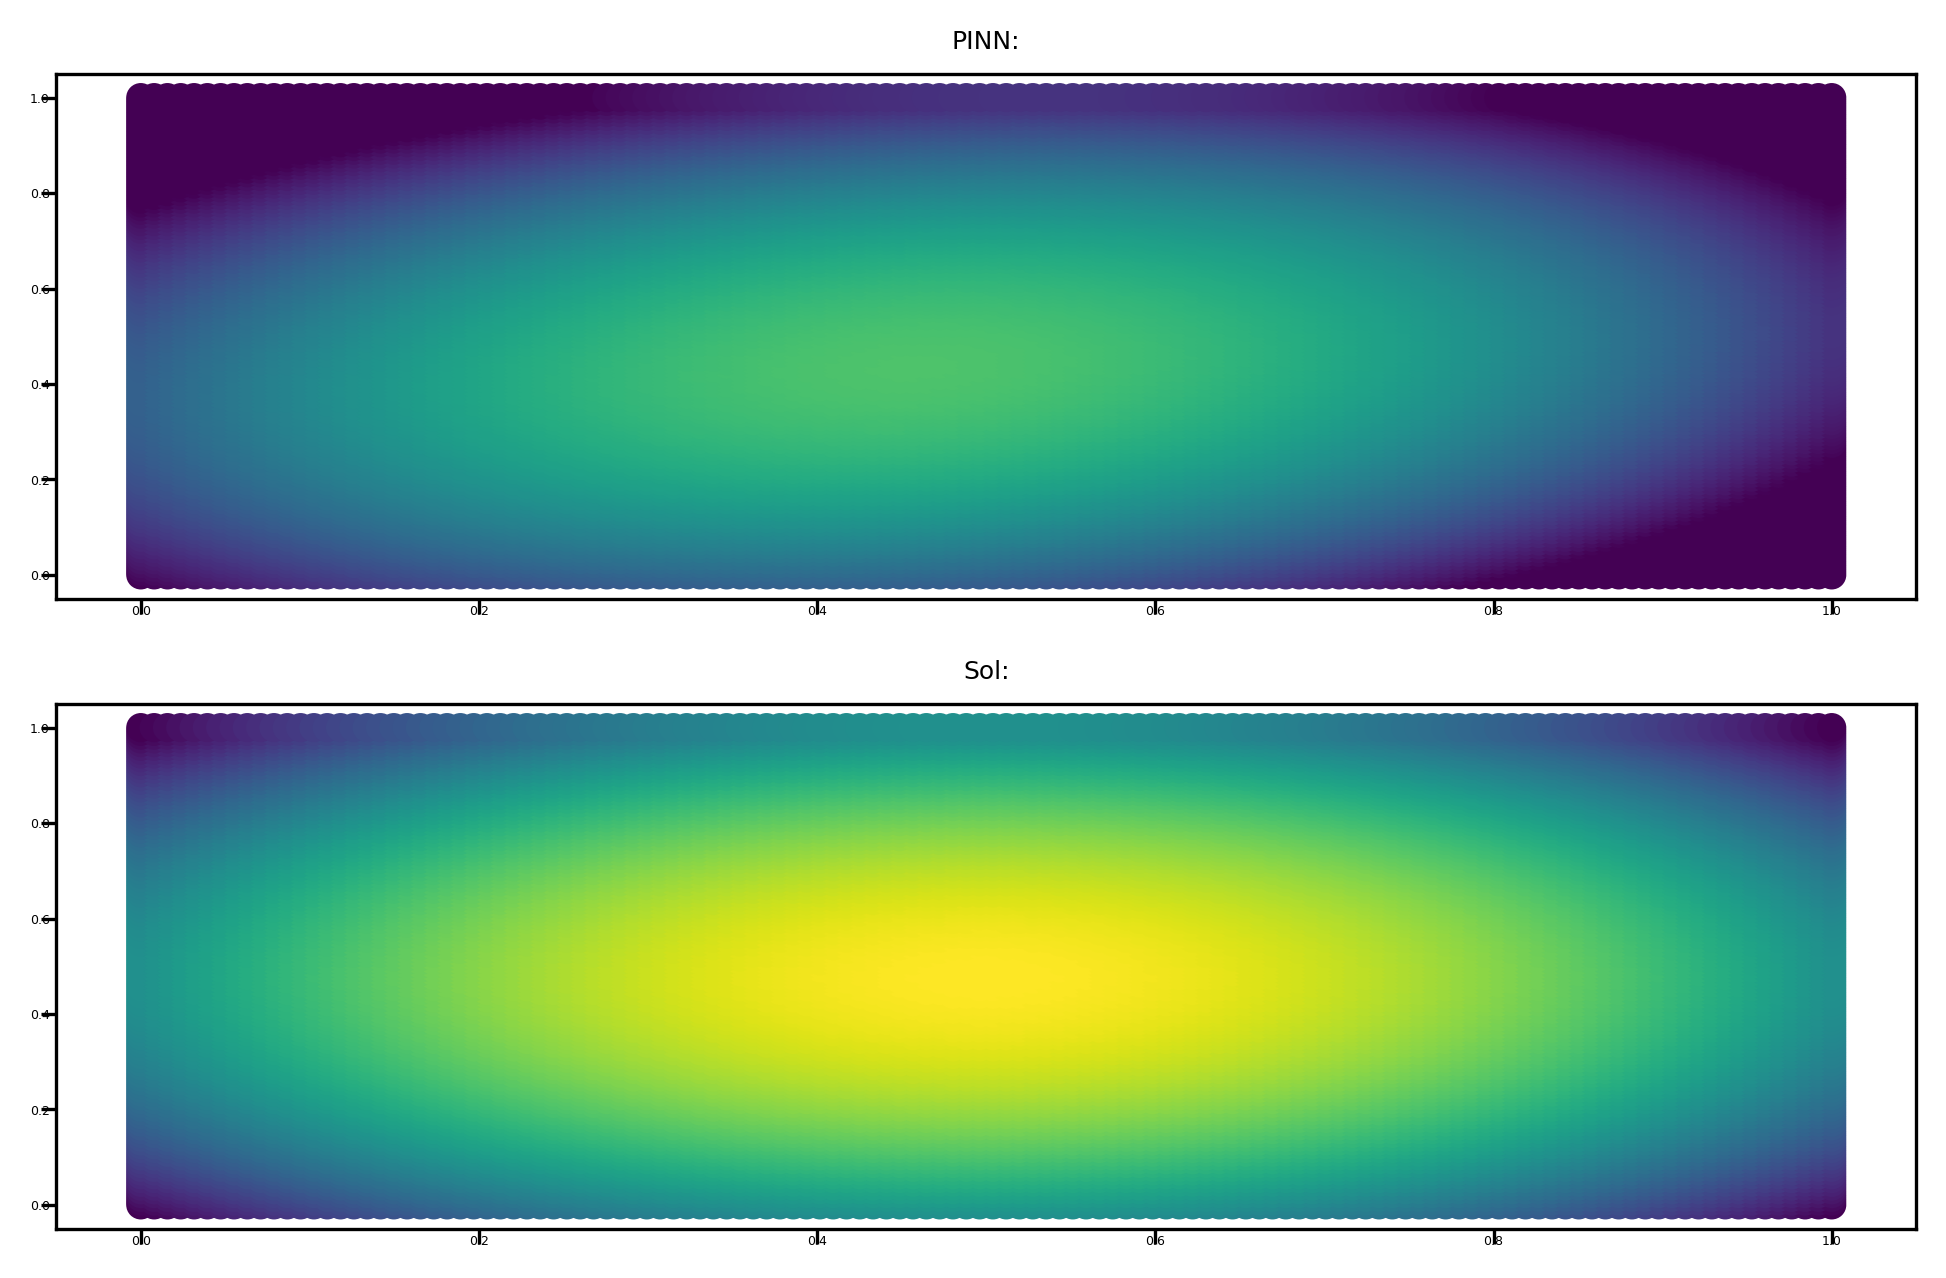

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from tqdm import tqdm

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = torch.nn.SiLU()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x


NN = TwoLayerNN(2, 500, 1)
state_dict = torch.load("trained_weights/weights_newPoisson_dNs_[10, 50, 100, 150, 200, 300, 400, 500]_s_[0, 0.2, 0.5, 0.7]_i_20000.pt",weights_only=True,map_location=torch.device('cpu'))['net_dN_500']
NN.load_state_dict(state_dict)
NN.eval()

def u_sol(x1, x2):
   return x1 - torch.square(x1) + x2 - torch.square(x2)

mesh = 128
a, b = 0, 1
no_times = 1
vmin, vmax = 0, 0.5

gs = GridSpec(2, no_times, width_ratios=[1]*no_times)
fig = plt.figure(figsize=(8, 5), dpi=300)

x, y = torch.meshgrid(
    torch.linspace(a, b, mesh),
    torch.linspace(a, b, mesh),
    indexing = "xy"
)

x_vec = x.reshape((mesh * mesh, 1))
y_vec = y.reshape((mesh * mesh, 1))

for i in range(no_times):
    z = NN(torch.cat(( x_vec, y_vec), 1))
    z = z.detach().cpu().numpy().reshape((mesh,mesh))

    ax = fig.add_subplot(gs[0, i])
    ax.set_title(f"PINN:",fontsize=6)
    ax.scatter(
        x, y, c=z, vmin=vmin, vmax=vmax
    )
    plt.tick_params(axis='both', which='major', labelsize=3)
    ax.tick_params(axis='both', which='major', pad=-2)

for i in range(no_times):
    z = u_sol(x_vec.cpu(), y_vec.cpu())
    z = z.detach().cpu().numpy().reshape((mesh,mesh))

    ax = fig.add_subplot(gs[1, i])
    ax.set_title(f"Sol:",fontsize=6)
    ax.scatter(
        x, y, c=z, vmin=vmin, vmax=vmax
    )
    plt.tick_params(axis='both', which='major', labelsize=3)
    ax.tick_params(axis='both', which='major', pad=-2)